## Distribution Plotting

In this part we look at the distribution of every numerical column, to spot unit problems and outliers before fixing them.

### Changes per column

- **Al_ppm:** The 10 EPRI-TR-101394s rows between 0.004 and 0.014 were entered in wt%, they are multiplied by 10,000. The 16 PantK-1990 `bw` rows, `"<0.01"` in the raw data and set to 0 by the missingness notebook, are set to 50.
- **Ti_ppm:** The same 16 PantK-1990 `bw` rows are set to 50.
- **charpy_temp_C:** The 188 of Ditt-0.5rch2 is set to NaN.
- **Every other column:** Unchanged. The other isolated values were checked against their own paper and kept.

### Operations in order

1. Load `../data/welddb_cleaned_missing.csv`, the output of the missingness notebook.
2. Describe every numerical column.
3. Plot a histogram of every numerical column with a log x-axis (`symlog` for the columns containing zeros), to spot unit problems.
4. Find the papers of the `Al_ppm` values below 1, and fix the values entered in wt%.
5. Plot the same histograms with a linear x-axis, to spot outliers.
6. Print the rows of the isolated values seen on the linear histograms, with their `weld_id`.
7. Print the other welds of the same papers, to judge each isolated value against its own study.
8. Set the Charpy temperature of Ditt-0.5rch2 to NaN.
9. Save to `../data/welddb_cleaned_units.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
df = pd.read_csv("../data/welddb_cleaned_missing.csv")

encoded_cols = ["AC_DC", "electrode_polarity", "AC_DC_unknown"] + [c for c in df.columns if c.startswith("weld_type_")]
numerical_cols = [c for c in df.columns if c not in encoded_cols + ["weld_id"]]

df[numerical_cols].describe()

,C,Si,Mn,S,P,Ni,Cr,Mo,V,O_ppm,Ti_ppm,N_ppm,Al_ppm,Nb_ppm,current_A,voltage_V,heat_input_kJ_mm,interpass_temp_C,pwht_temp_C,pwht_time_h,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct,charpy_temp_C,charpy_toughness_J
count,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,1639.000000,767.000000,738.000000,687.000000,692.000000,879.000000,879.00000
mean,0.075175,0.328603,1.200134,0.009466,0.012819,0.175937,1.004611,0.230955,0.026790,437.535082,43.985052,103.755339,70.358499,60.237340,271.755034,26.892447,1.677810,203.455156,304.674192,5.049652,506.363233,594.386314,26.315866,72.011416,-34.606371,87.68942
std,0.023635,0.112800,0.382271,0.011230,0.019555,0.552650,2.341391,0.409610,0.068684,129.344397,82.992133,83.056658,109.983215,168.891178,182.865826,12.040933,1.264843,38.564872,285.498003,6.096034,91.319972,88.636238,4.862269,8.803713,34.738624,50.11670
min,0.029000,0.040000,0.270000,0.001000,0.002000,0.000000,0.000000,0.000000,0.000000,132.000000,0.000000,21.000000,0.000000,0.000000,115.000000,11.500000,0.600000,20.000000,0.000000,0.000000,315.000000,447.000000,10.600000,17.000000,-114.000000,3.00000
25%,0.061000,0.270000,0.930000,0.006000,0.007000,0.000000,0.000000,0.000000,0.000000,397.000000,0.000000,74.000000,30.000000,0.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,443.000000,532.775000,23.000000,68.500000,-60.000000,38.00000
50%,0.074000,0.320000,1.250000,0.007000,0.010000,0.000000,0.000000,0.000000,0.000000,423.000000,5.000000,82.000000,37.500000,0.000000,170.000000,21.000000,1.000000,200.000000,250.000000,2.000000,494.000000,575.500000,26.800000,75.000000,-40.000000,100.00000
75%,0.084000,0.360000,1.440000,0.010000,0.014000,0.030000,0.415000,0.270000,0.010000,453.000000,43.000000,94.000000,50.000000,2.000000,300.000000,30.000000,2.000000,200.000000,580.000000,10.000000,555.000000,647.000000,30.000000,78.000000,-17.500000,100.00000
max,0.180000,1.140000,2.250000,0.140000,0.250000,3.500000,10.200000,1.500000,0.320000,1650.000000,690.000000,552.000000,680.000000,1000.000000,900.000000,75.360000,7.900000,300.000000,760.000000,24.000000,920.000000,1151.000000,37.000000,83.000000,188.000000,270.00000


The encoded columns (`AC_DC`, `electrode_polarity`, `AC_DC_unknown` and the `weld_type_` columns) and `weld_id` are left out, their distribution was already looked at in the missingness notebook.

The units come from `welddb.info`: columns 1 to 12 (C to W) are in *"weight%"*, columns 13 to 21 (O to Sb) are in *"parts per million by weight"*. `welddb.info` gives no expected range for any column, we compare each columns in relation to their own values.

Initial observations:
- **charpy_temp_C:** The max (188) is far above the 75th percentile (-17.5).
- **uts_MPa:** The max (1151) is far above the 75th percentile (647).
- **Ni, Cr, Mo, V, Ti_ppm, Al_ppm, Nb_ppm, pwht_temp_C, pwht_time_h:** The min is 0.

`describe()` only gives the min, the quartiles and the max, so it says nothing about how the values are spread in between. This is why we plot the histograms.

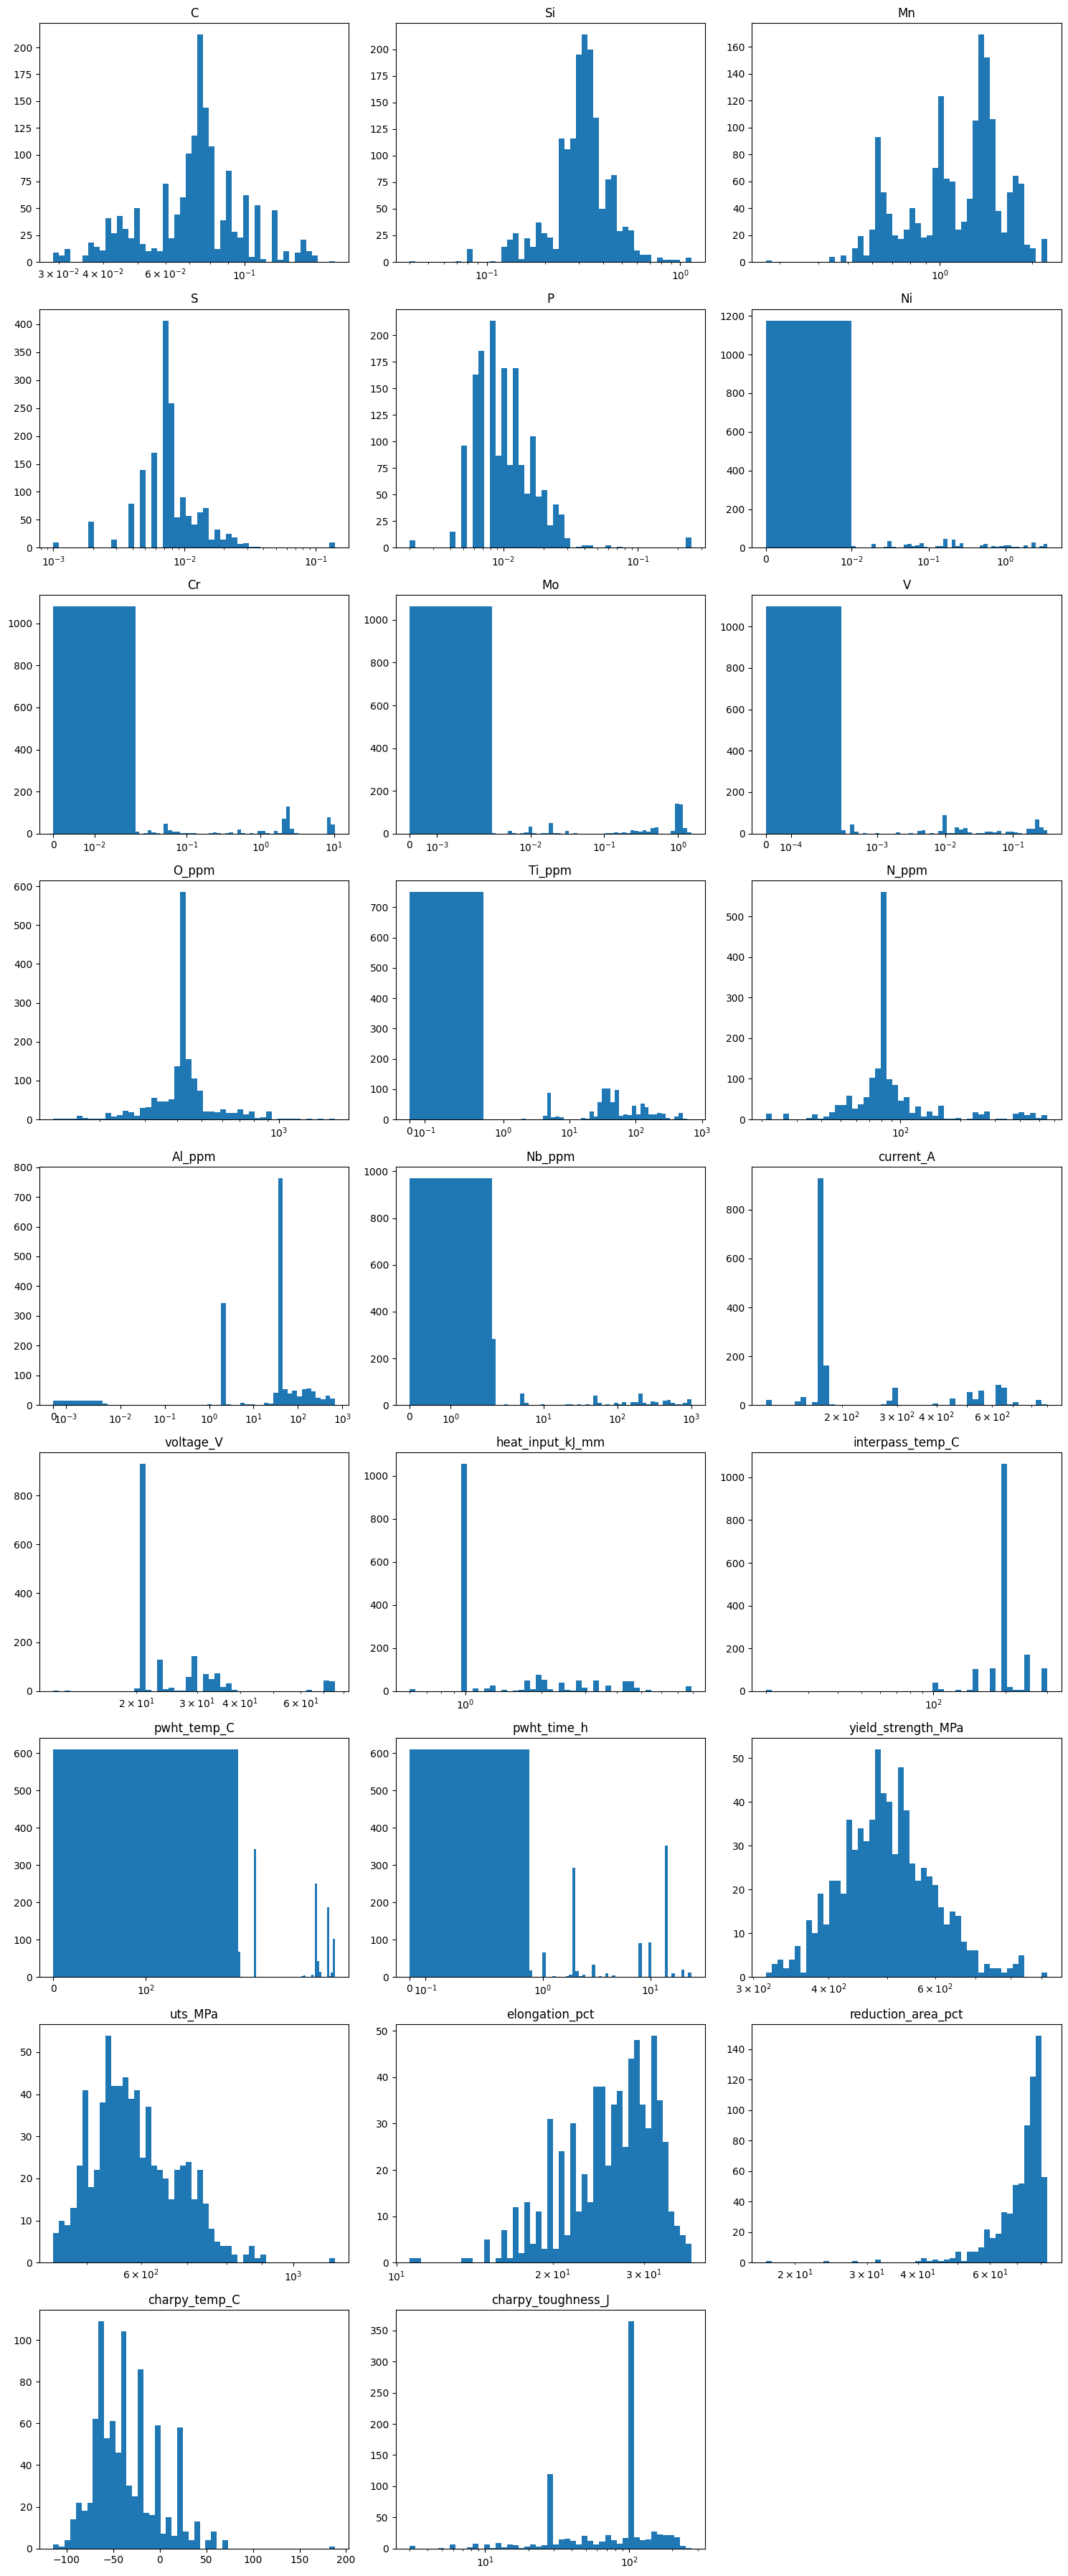

In [4]:
n_rows = -(-len(numerical_cols) // 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
for ax, col in zip(axes.flat, numerical_cols):
    x = df[col].dropna()
    if (x < 0).any():
        ax.hist(x, bins=50)
    elif (x == 0).any():
        min_pos = x[x > 0].min()
        ax.hist(x, bins=np.concatenate([[0], np.geomspace(min_pos, x.max(), 50)]))
        ax.set_xscale("symlog", linthresh=min_pos)
    else:
        ax.hist(x, bins=np.geomspace(x.min(), x.max(), 50))
        ax.set_xscale("log")
    ax.set_title(col)
for ax in axes.flat[len(numerical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

The x-axis is logarithmic, so values of different orders of magnitude end up in separate bars instead of sharing the first bin of a linear axis. The zeros are part of the distribution, but zero cannot be placed on a log axis. For the columns containing zeros the axis is therefore linear between 0 and the smallest non-zero value, and logarithmic above it (`symlog`), so the first bar holds the zeros. `charpy_temp_C` has negative values, so it keeps a linear axis.

- **Al_ppm:** The first bar (the zeros) and a few values around 0.01 sit three orders of magnitude below the rest of the column (25th percentile at 30 ppm). `welddb.info` gives column 16 in *"parts per million by weight"*. A value of 0.01 **wt%** is 100 ppm, which falls right inside the bulk of the column, so the values around 0.01 look like they were entered in wt% instead of ppm.

In [5]:
df.loc[df["Al_ppm"] < 1, ["weld_id", "Al_ppm", "Ti_ppm"]]

,weld_id,Al_ppm,Ti_ppm
1191,PantK-1990-bw1.0,0.000,0.0
1192,PantK-1990-bw1.1,0.000,0.0
1193,PantK-1990-bw1.2,0.000,0.0
1194,PantK-1990-bw1.3,0.000,0.0
1195,PantK-1990-bw2.0,0.000,0.0
1196,PantK-1990-bw2.1,0.000,0.0
1197,PantK-1990-bw2.2,0.000,0.0
1198,PantK-1990-bw2.3,0.000,0.0
1199,PantK-1990-bw3.0,0.000,0.0
1200,PantK-1990-bw3.1,0.000,0.0


The rows below 1 ppm of Al come from two papers: the values around 0.01 come from EPRI-TR-101394s, the zeros from PantK-1990. The PantK-1990 rows also have a Ti of 0.

In [6]:
epri = df[df["weld_id"].str.startswith("EPRI-TR-101394s")]
epri[["weld_id", "Al_ppm"]]

,weld_id,Al_ppm
1207,EPRI-TR-101394s-E9SA6,160.000
1208,EPRI-TR-101394s-E9SA6,160.000
1209,EPRI-TR-101394s-E9SA8,0.014
1210,EPRI-TR-101394s-E9SA8,0.014
1211,EPRI-TR-101394s-E9GT3,0.005
1212,EPRI-TR-101394s-E9GT3,0.005
1213,EPRI-TR-101394s-E9GT4,0.004
1214,EPRI-TR-101394s-E9GT4,0.004
1215,EPRI-TR-101394s-E9GM2,0.004
1216,EPRI-TR-101394s-E9GM2,0.004


- **Al_ppm (EPRI-TR-101394s):** One weld of the paper, E9SA6, has an Al of 160 ppm. The 5 other welds have an Al between 0.004 and 0.014. Multiplied by 10,000 (wt% to ppm), they become 40 to 140 ppm, the same range as E9SA6. These 5 welds were entered in wt% instead of ppm.

In [7]:
raw = pd.read_csv("../data/welddb.csv")
raw_pantk = raw[raw["weld_id"].str.startswith("PantK-1990")]
raw_pantk[["weld_id", "Al_ppm", "Ti_ppm"]]

,weld_id,Al_ppm,Ti_ppm
1166,PantK-1990-w1,<100,<100
1167,PantK-1990-w2,<100,<100
1168,PantK-1990-w3,<100,<100
1169,PantK-1990-w4.0,<100,<100
1170,PantK-1990-w4.1,<100,<100
1171,PantK-1990-w4.2,<100,<100
1172,PantK-1990-w4.3,<100,<100
1173,PantK-1990-w4.4,<100,<100
1174,PantK-1990-w4.5,<100,<100
1175,PantK-1990-w4.6,<100,<100


The zeros do not show where they come from, so we look at the raw values of PantK-1990, before the missingness notebook.

- **Al_ppm, Ti_ppm (PantK-1990):** The `w` welds have Al and Ti at `"<100"`, which the half limit imputation turned into 50. The `bw` welds have `"<0.01"`, which it turned into 0. A value of 0.01 wt% is 100 ppm, so `"<0.01"` is the same `"<100"` limit as the rest of the paper, entered in wt% instead of ppm. The `bw` welds therefore get 50, like the `w` welds.

In [8]:
epri_wt = df["weld_id"].str.startswith("EPRI-TR-101394s") & (df["Al_ppm"] < 1)
df.loc[epri_wt, "Al_ppm"] = (df.loc[epri_wt, "Al_ppm"] * 10000).round()

pantk_bw = df["weld_id"].str.startswith("PantK-1990-bw")
df.loc[pantk_bw, ["Al_ppm", "Ti_ppm"]] = 50

df.loc[epri_wt | pantk_bw, ["weld_id", "Al_ppm", "Ti_ppm"]]

,weld_id,Al_ppm,Ti_ppm
1191,PantK-1990-bw1.0,50.0,50.0
1192,PantK-1990-bw1.1,50.0,50.0
1193,PantK-1990-bw1.2,50.0,50.0
1194,PantK-1990-bw1.3,50.0,50.0
1195,PantK-1990-bw2.0,50.0,50.0
1196,PantK-1990-bw2.1,50.0,50.0
1197,PantK-1990-bw2.2,50.0,50.0
1198,PantK-1990-bw2.3,50.0,50.0
1199,PantK-1990-bw3.0,50.0,50.0
1200,PantK-1990-bw3.1,50.0,50.0


The 10 EPRI-TR-101394s rows below 1 ppm are converted from wt% to ppm, and the 16 PantK-1990 `bw` rows get 50 for Al and Ti.

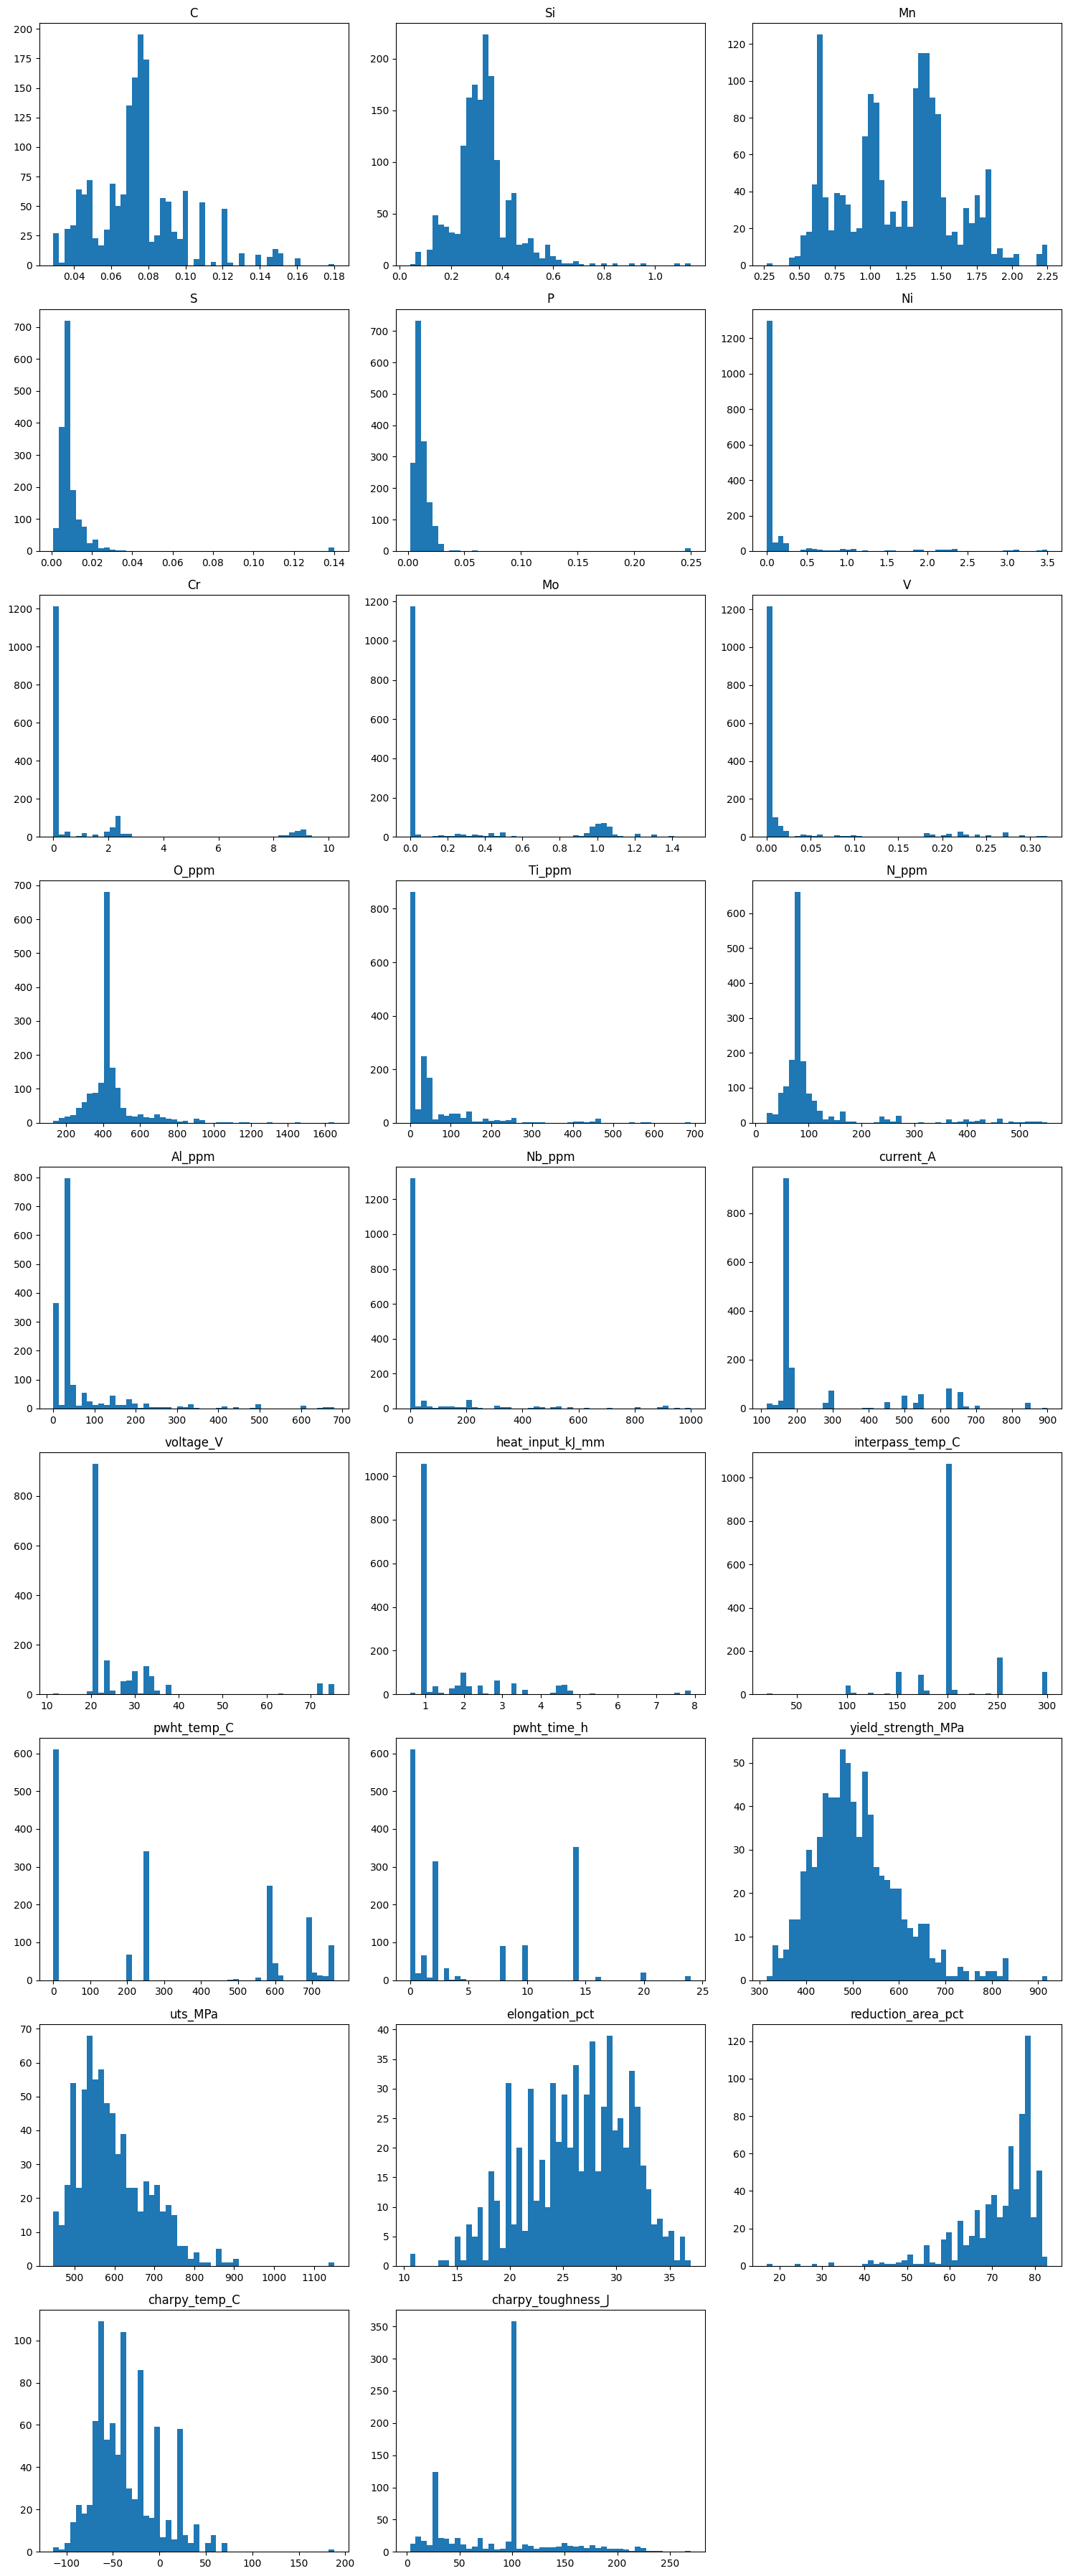

In [9]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
for ax, col in zip(axes.flat, numerical_cols):
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(col)
for ax in axes.flat[len(numerical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

The same histograms with a linear x-axis. The log axis compresses the large values together, while the linear axis keeps the real distance between values, so a value far from the rest shows up as an isolated bar after an empty gap.

- **High isolated values:** `S` (around 0.14), `P` (around 0.25), `yield_strength_MPa` (around 920), `uts_MPa` (around 1150) and `charpy_temp_C` (around 190).
- **Low isolated values:** `Mn` (around 0.27), `interpass_temp_C` (around 20), `elongation_pct` (around 11) and `reduction_area_pct` (under 20).

Before the fix above, the values around 0.01 in `Al_ppm` fell into the first bar with the zeros, which we couldn't have observed with linear axes.

In [10]:
candidates = {
    "S": df["S"] > 0.1,
    "P": df["P"] > 0.2,
    "Mn": df["Mn"] < 0.3,
    "interpass_temp_C": df["interpass_temp_C"] < 50,
    "yield_strength_MPa": df["yield_strength_MPa"] > 900,
    "uts_MPa": df["uts_MPa"] > 1000,
    "elongation_pct": df["elongation_pct"] < 12,
    "reduction_area_pct": df["reduction_area_pct"] < 20,
    "charpy_temp_C": df["charpy_temp_C"] > 100,
}

for col, mask in candidates.items():
    display(df.loc[mask, [col, "weld_id"]])

,S,weld_id
1354,0.14,Mart-G
1355,0.14,Mart-Ga
1356,0.14,Mart-Gb
1357,0.14,Mart-Gc
1358,0.14,Mart-Gd
1359,0.14,Mart-Ge
1360,0.14,Mart-Gf
1361,0.14,Mart-Gg
1362,0.14,Mart-Gh
1363,0.14,Mart-Gi


,P,weld_id
1354,0.25,Mart-G
1355,0.25,Mart-Ga
1356,0.25,Mart-Gb
1357,0.25,Mart-Gc
1358,0.25,Mart-Gd
1359,0.25,Mart-Ge
1360,0.25,Mart-Gf
1361,0.25,Mart-Gg
1362,0.25,Mart-Gh
1363,0.25,Mart-Gi


,Mn,weld_id
1379,0.27,Wolst-1974-AM1


,interpass_temp_C,weld_id
1084,20.0,Evans-intpss-1978-A20
1085,20.0,Evans-intpss-1978-B20
1086,20.0,Evans-intpss-1978-C20
1087,20.0,Evans-intpss-1978-D20


,yield_strength_MPa,weld_id
722,920.0,Evans-AlEl9Cr1Mo-1994-3Ni


,uts_MPa,weld_id
722,1151.0,Evans-AlEl9Cr1Mo-1994-3Ni


,elongation_pct,weld_id
722,10.6,Evans-AlEl9Cr1Mo-1994-3Ni
1333,11.0,Mart-E


,reduction_area_pct,weld_id
1377,17.0,Wolst-1974-N


,charpy_temp_C,weld_id
1416,188.0,Ditt-0.5rch2


The thresholds are read from the linear histograms above, each one separates the isolated values from the rest of the column. Every flagged row is printed with its `weld_id`, to see which paper it comes from.

In [11]:
mart = df[df["weld_id"].str.startswith("Mart-")]
mart = mart.dropna(subset=["yield_strength_MPa"])
mart[["weld_id", "S", "P", "yield_strength_MPa", "uts_MPa", "elongation_pct", "reduction_area_pct"]]

,weld_id,S,P,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct
1294,Mart-A,0.010,0.010,440.0,540.0,24.0,67.0
1306,Mart-B,0.014,0.016,506.0,598.0,22.0,70.0
1315,Mart-C,0.011,0.017,505.0,600.0,19.0,69.0
1323,Mart-D,0.012,0.015,520.0,620.0,20.0,54.0
1333,Mart-E,0.015,0.016,537.0,620.0,11.0,24.0
1343,Mart-F,0.009,0.024,595.0,675.0,24.0,69.0
1354,Mart-G,0.140,0.250,643.0,708.0,16.0,32.0


Each flagged value is compared to the other welds of the same paper, since we decided a value is only suspicious if it does not fit its own paper.

In the data, one weld is spread over several rows: one row with the strength results, and one row per Charpy test. Keeping only the rows with a `yield_strength_MPa` leaves one row per weld.

- **S, P (Mart-G):** Mart-G has S = 0.14 and P = 0.25. The 6 other welds of the paper have S around 0.01 and P around 0.02, so Mart-G is 10 times higher on both. The data cannot tell us if this is on purpose or a typo.

- **elongation_pct (Mart-E):** Mart-E has an elongation of 11, the lowest of the paper. Its `reduction_area_pct` (24) is also the lowest of the paper. Both columns measure how much the metal deforms before breaking, so the two values agree. Not an error.

In [12]:
wolst = df[df["weld_id"].str.startswith("Wolst-1974")]
wolst = wolst.dropna(subset=["yield_strength_MPa"])
wolst[["weld_id", "Mn", "yield_strength_MPa", "uts_MPa", "elongation_pct", "reduction_area_pct"]]

,weld_id,Mn,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct
1370,Wolst-1974-A,0.58,593.0,698.0,17.0,67.0
1371,Wolst-1974-B,0.73,591.0,705.0,17.0,70.0
1372,Wolst-1974-C,0.76,614.0,713.0,18.0,67.0
1373,Wolst-1974-E,0.94,546.0,658.0,18.0,65.0
1374,Wolst-1974-F,0.55,464.0,578.0,23.0,71.0
1375,Wolst-1974-G,0.88,646.0,737.0,18.0,63.0
1376,Wolst-1974-K,0.84,536.0,652.0,20.0,73.0
1377,Wolst-1974-N,0.80,546.0,648.0,18.0,17.0
1378,Wolst-1974-Y,0.77,581.0,693.0,20.0,69.0
1379,Wolst-1974-AM1,0.27,537.0,648.0,22.0,65.0


Same filter as for Mart, one row per weld.

- **Mn (Wolst-1974-AM1):** AM1 has Mn = 0.27, the lowest of the whole column. The welds AM1, AM2, AM3 and AM4 have Mn = 0.27, 0.45, 0.67 and 0.80, so the paper increases Mn step by step on purpose, and 0.27 is the first step. Not an error.

- **reduction_area_pct (Wolst-1974-N):** N has a reduction of area of 17, while every other weld of the paper is between 58 and 73. The other results of N (yield 546, UTS 648, elongation 18) are normal for the paper. Unlike Mart-E, nothing else in the row is low. Suspicious.

In [13]:
intpss = df[df["weld_id"].str.startswith("Evans-intpss-1978")]
intpss[["weld_id", "interpass_temp_C"]]

,weld_id,interpass_temp_C
1084,Evans-intpss-1978-A20,20.0
1085,Evans-intpss-1978-B20,20.0
1086,Evans-intpss-1978-C20,20.0
1087,Evans-intpss-1978-D20,20.0
1088,Evans-intpss-1978-A150,150.0
1089,Evans-intpss-1978-B150,150.0
1090,Evans-intpss-1978-C150,150.0
1091,Evans-intpss-1978-D150,150.0
1092,Evans-intpss-1978-A240,240.0
1093,Evans-intpss-1978-B240,240.0


- **interpass_temp_C (Evans-intpss-1978):** 4 welds have an interpass temperature of 20. The paper makes the welds A, B, C and D each at 20, 150, 240 and 300, and the weld name ends with the temperature (`A20`, `A150`...). 20 is one of the 4 temperatures chosen by the paper. Not an error.

In [14]:
evans_ni = df[df["weld_id"].str.startswith("Evans-AlEl9Cr1Mo-1994")]
evans_ni[["weld_id", "Ni", "yield_strength_MPa", "uts_MPa", "elongation_pct", "reduction_area_pct"]]

,weld_id,Ni,yield_strength_MPa,uts_MPa,elongation_pct,reduction_area_pct
719,Evans-AlEl9Cr1Mo-1994--,0.08,617.0,762.0,18.4,61.2
720,Evans-AlEl9Cr1Mo-1994-1Ni,0.98,551.0,751.0,19.6,64.5
721,Evans-AlEl9Cr1Mo-1994-2Ni,1.92,672.0,866.0,13.6,56.8
722,Evans-AlEl9Cr1Mo-1994-3Ni,3.01,920.0,1151.0,10.6,47.6
723,Evans-AlEl9Cr1Mo-1994-1Co,0.00,525.0,696.0,19.8,64.4
724,Evans-AlEl9Cr1Mo-1994-2Co,0.00,526.0,690.0,21.9,66.0
725,Evans-AlEl9Cr1Mo-1994-3Co,0.00,481.0,672.0,23.7,66.7
726,Evans-AlEl9Cr1Mo-1994-1W,0.00,526.0,702.0,19.6,59.3
727,Evans-AlEl9Cr1Mo-1994-2W,0.00,515.0,698.0,18.9,59.0
728,Evans-AlEl9Cr1Mo-1994-3W,0.00,489.0,686.0,18.7,49.6


- **yield_strength_MPa, uts_MPa, elongation_pct (Evans-AlEl9Cr1Mo-1994-3Ni):** The 3 flagged values are on the same weld, 3Ni. The paper adds more and more Ni: the welds `--`, `1Ni`, `2Ni` and `3Ni` have Ni = 0.08, 0.98, 1.92 and 3.01. From `1Ni` to `3Ni`, the yield strength and the UTS go up and the elongation goes down. `3Ni` has the most Ni, so its values are the end of that trend. Not an error.

In [15]:
ditt = df[df["weld_id"].str.startswith("Ditt-")]
ditt = ditt.dropna(subset=["charpy_temp_C"])
ditt[["weld_id", "charpy_temp_C", "charpy_toughness_J"]]

,weld_id,charpy_temp_C,charpy_toughness_J
1403,Ditt-oatch1,20.0,231.0
1404,Ditt-oatch2,-10.0,197.0
1405,Ditt-oatch3,-30.0,170.0
1407,Ditt-0.5tch1,20.0,224.0
1408,Ditt-0.5tch2,-10.0,203.0
1409,Ditt-0.5tch3,-30.0,171.0
1411,Ditt-0.5ach1,20.0,227.0
1412,Ditt-0.5ach2,-10.0,175.0
1413,Ditt-0.5ach3,-30.0,152.0
1415,Ditt-0.5rch1,20.0,221.0


This time only the rows with a Charpy temperature are kept.

- **charpy_temp_C (Ditt-0.5rch2):** 0.5rch2 has a Charpy temperature of 188. The paper tests every weld 3 times: at 20 (`ch1`), -10 (`ch2`) and -30 (`ch3`). 0.5rch2 is the only `ch2` not at -10. Also, in every other weld the energy (`charpy_toughness_J`) goes down when the temperature goes down. Following that, 188 should give more energy than 20 (221), but it gives less (141).

In [16]:
df.loc[df["weld_id"] == "Ditt-0.5rch2", "charpy_temp_C"] = np.nan

df.loc[df["weld_id"] == "Ditt-0.5rch2", ["weld_id", "charpy_temp_C", "charpy_toughness_J"]]

,weld_id,charpy_temp_C,charpy_toughness_J
1416,Ditt-0.5rch2,NaN,141.0


- **charpy_temp_C (Ditt-0.5rch2):** Set to NaN rather than a specific value because we don't know.

In [17]:
df.to_csv("../data/welddb_cleaned_units.csv", index=False)

print(df.shape)

(1639, 37)
